<a href="https://colab.research.google.com/github/AbdullahMakhdoom/Employee_Retention_Prediction/blob/main/Employee_Retention_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Employee Retention Prediction

## 1.1 Business Overview

Employee turnover is a critical challenge for organizations across industries. When valued employees leave, companies face significant costs including recruitment expenses, training new hires, lost productivity, and decreased team morale. For a typical organization, replacing a salaried employee can cost between 6 to 9 months of their salary on average.

Human Resources departments need tools to identify employees who might be considering leaving, allowing them to intervene proactively with retention strategies. Currently, many organizations rely on exit interviews after employees have already left, missing the opportunity for preventive action.

This project aims to address this challenge by building a predictive model that analyzes employee data to identify those at risk of leaving. By understanding the key factors that drive attrition, HR teams can implement targeted retention programs, improve employee satisfaction, and ultimately reduce turnover costs.


## 1.2 Problem Statement

The HR department of a large organization wants to understand why employees leave and identify those who might be at risk of leaving in the future. Currently, they have historical data on employees who stayed and those who left, but they lack a systematic way to:

- Identify the key factors that influence employee turnover
- Predict which current employees are at high risk of leaving
- Prioritize retention efforts for maximum impact
- Quantify the potential business impact of different retention strategies


### 1.3 Business Objectives

#### Main Objective
To develop a machine learning model that accurately predicts employee turnover and provides actionable insights for HR decision-making.

#### Specific Objectives
1. Which factors are most strongly associated with employee turnover?
2. How accurately can we predict whether an employee will leave?
3. What profiles characterize high-risk employees?
4. What actionable recommendations can be derived to improve retention?


### 1.4 Success Criteria

| Criteria | Target |
|----------|--------|
| Predictive Performance | Accuracy > 90% on test data |
| Model Stability | Low variance between CV and test |
| Interpretability | Clear identification of key drivers |
| Business Relevance | Actionable insights for HR |
| ROI Potential | 30% reduction in voluntary turnover |

2. DATA UNDERSTANDING

## 2. Data Understanding

### 2.1 Data Source

The dataset used in this project is a collection of employee records from an organization's HR database. It contains information about employee demographics, job-related factors, and whether they left the company.

**Dataset Size:** 14,999 employee records  
**Features:** 9 predictor variables + 1 target variable  
**Source:** HR database (anonymized)


### 2.2 Feature Description

| Feature | Type | Description | Range |
|---------|------|-------------|-------|
| empid | Integer | Unique employee identifier | 1-14999 |
| satisfaction_level | Float | Employee satisfaction score | 0-1 |
| last_evaluation | Float | Last performance evaluation score | 0-1 |
| number_project | Integer | Number of projects assigned | 2-7 |
| average_monthly_hours | Integer | Average hours worked per month | 96-310 |
| time_spend_company | Integer | Years at the company | 2-10 |
| Work_accident | Binary | Whether had work accident | 0/1 |
| promotion_last_5years | Binary | Whether promoted in last 5 years | 0/1 |
| salary | Categorical | Salary level | low/medium/high |
| left | Binary | **TARGET:** Whether employee left | 0/1 |

### 2.3 Data Quality Assessment

| Quality Dimension | Assessment | Action Taken |
|-------------------|------------|--------------|
| Completeness | satisfaction_level had 2 missing values | Imputed with mean (0.61) |
| Consistency | Column name typo 'average_montly_hours' | Renamed to 'average_monthly_hours' |
| Accuracy | No明显的 errors detected | - |
| Validity | All data types correct | - |

### 2.4 Key Stakeholders

1. **HR Managers and Business Partners**
   - Use insights to design retention programs
   - Identify at-risk employees for intervention

2. **Senior Leadership**
   - Understand organizational retention challenges
   - Allocate resources for retention initiatives

3. **Team Leaders and Managers**
   - Identify team members who may need support
   - Improve management practices based on insights

4. **Employees**
   - Benefit from improved workplace conditions
   - Experience better career development opportunities
"""))

In [51]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


downloading the dataset from GitHub using curl command

In [52]:
# download the dataset .csv from github 
!curl -LJO https://raw.githubusercontent.com/CODESTUDIO-GIT/endtoend-ml-projects/master/hr_employee_churn_data.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0  517k    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  517k  100  517k    0     0   353k      0  0:00:01  0:00:01 --:--:--  355k


In [53]:
# create dataframe to load dataset
df = pd.read_csv("hr_employee_churn_data.csv")

In [54]:
df.head()

,empid,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary,left
0,1,0.38,0.53,2,157,3,0,0,low,1
1,2,0.80,0.86,5,262,6,0,0,medium,1
2,3,0.11,0.88,7,272,4,0,0,medium,1
3,4,0.72,0.87,5,223,5,0,0,low,1
4,5,0.37,0.52,2,159,3,0,0,low,1


In [55]:
# spelling correction 
df.rename(columns = {'average_montly_hours' : 'average_monthly_hours'}, inplace=True)

In [56]:
df.shape

(14999, 10)

About 15,000 employees 

In [57]:
# checking the column names and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   empid                  14999 non-null  int64  
 1   satisfaction_level     14997 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_monthly_hours  14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   salary                 14999 non-null  object 
 9   left                   14999 non-null  int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 1.1+ MB


In [58]:
df.describe()

,empid,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,promotion_last_5years,left
count,14999.000000,14997.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,7500.000000,0.612863,0.716102,3.803054,201.050337,3.498233,0.144610,0.021268,0.238083
std,4329.982679,0.248634,0.171169,1.232592,49.943099,1.460136,0.351719,0.144281,0.425924
min,1.000000,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,3750.500000,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,7500.000000,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,11249.500000,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,14999.000000,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


satisfaction levels range from 0.09 to 1.0, with most people around 0.61

### Handling Categorical Features

In [59]:
df['Work_accident'].unique()

array([0, 1])

In [60]:
df['promotion_last_5years'].unique()


array([0, 1])

VISUALIZATION

visualizing the split between those who stay and those who leave.


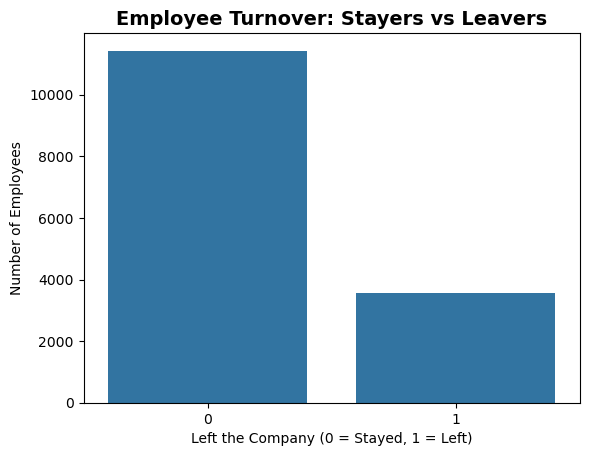

In [61]:
sns.countplot(x='left', data=df)
plt.title('Employee Turnover: Stayers vs Leavers', fontsize=14, fontweight='bold')
plt.xlabel('Left the Company (0 = Stayed, 1 = Left)')
plt.ylabel('Number of Employees')
plt.show()

This is a binary classification problem:

1 → Employee leaves

0 → Employee stays

Looking at this chart, I noticed that this is an imbalanced dataset as the number of employees who went away does not match the number of the ones that remained. That is really quite realistic! Even in real life, a majority of people do not quit their jobs annually. However, it is an imbalance that I will have to take note of when constructing models in the future.

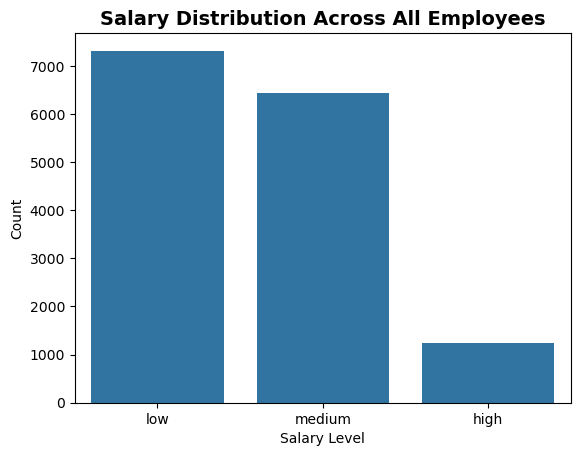

In [62]:
sns.countplot(x='salary', data=df)
plt.title('Salary Distribution Across All Employees', fontsize=14, fontweight='bold')
plt.xlabel('Salary Level')
plt.ylabel('Count')
plt.show()


Employees with low salary have higher attrition rate.(whether employees leave or stay)



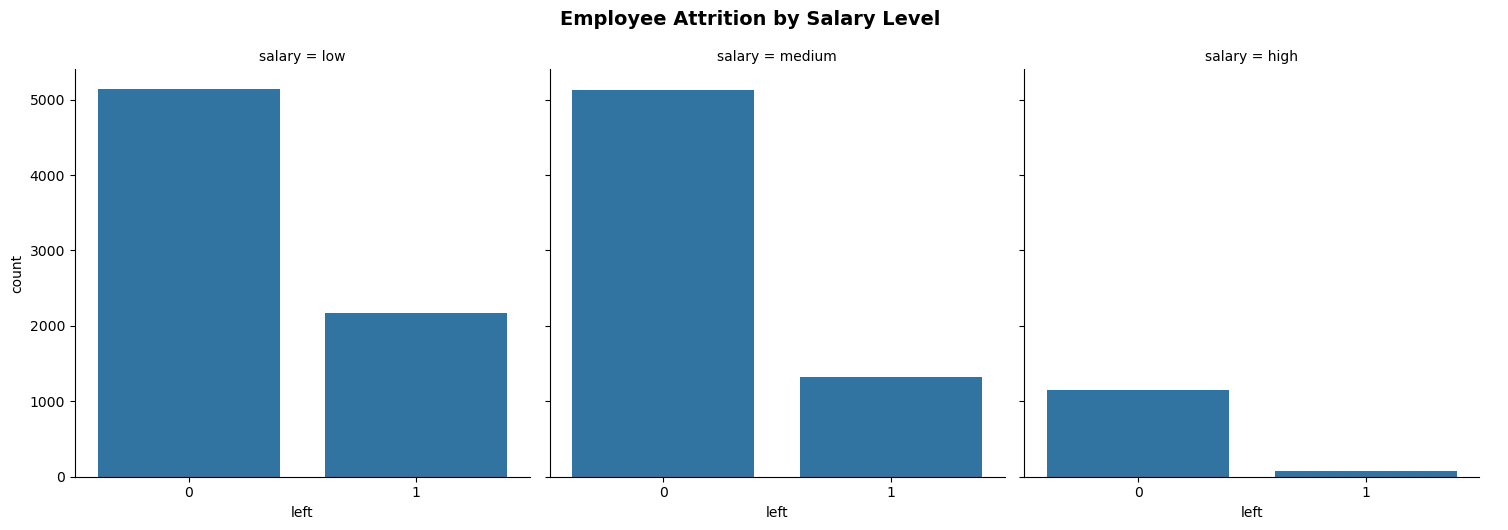

In [63]:
sns.catplot(x='left', col='salary', kind='count', data=df)
plt.suptitle('Employee Attrition by Salary Level', y=1.05, fontsize=14, fontweight='bold')
plt.show()

Lowly paid employees have greater attrition rate. This is intuitively true - as long as you are not well paid, you will seek better employment. Salary is one of the major factors that affect employee retention.

Salary is a significant factor influencing employee retention.



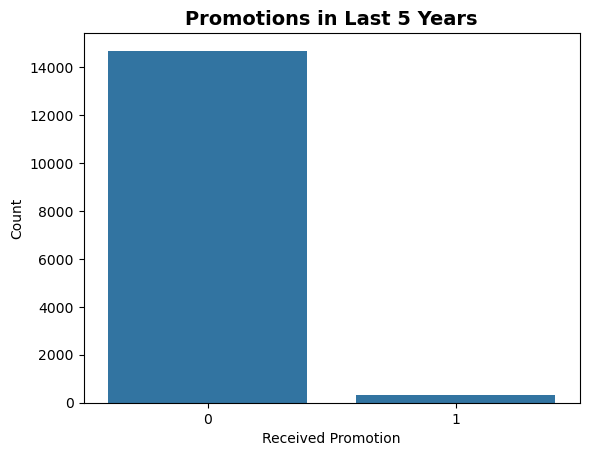

In [64]:
sns.countplot(x='promotion_last_5years', data=df)
plt.title('Promotions in Last 5 Years', fontsize=14, fontweight='bold')
plt.xlabel('Received Promotion')
plt.ylabel('Count')
plt.show()

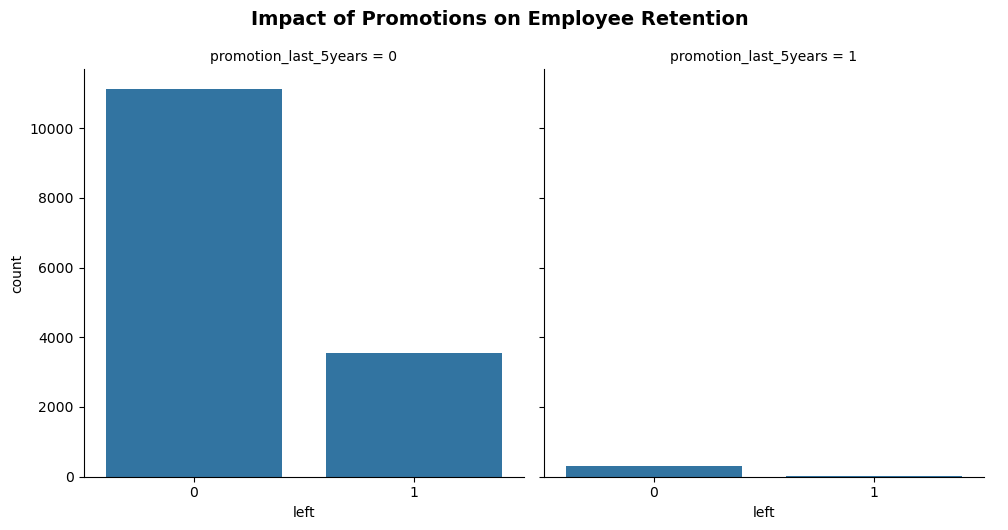

In [65]:
sns.catplot(x='left', col='promotion_last_5years', kind='count', data=df)
plt.suptitle('Impact of Promotions on Employee Retention', y=1.05, fontsize=14, fontweight='bold')
plt.show()

The trend is crystal clear - Employees that have not been promoted have better chances of leaving. Retention is greatly influenced by career growth opportunities. This rings when I consider my own career, we all want to feel that we are growing.

Career growth opportunities strongly affect retention.

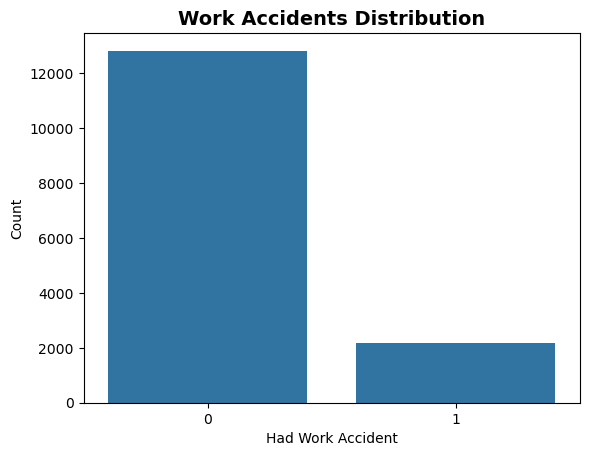

In [66]:
sns.countplot(x='Work_accident', data=df)
plt.title('Work Accidents Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Had Work Accident')
plt.ylabel('Count')
plt.show()

Work accidents do not significantly influence attrition.

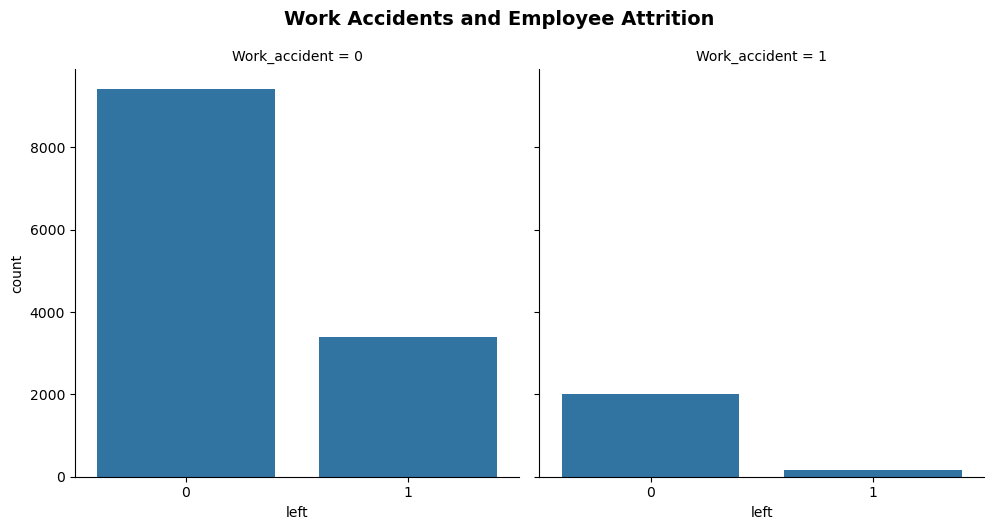

In [67]:
sns.catplot(x='left', col='Work_accident', kind='count', data=df)
plt.suptitle('Work Accidents and Employee Attrition', y=1.05, fontsize=14, fontweight='bold')
plt.show()

Based on these plots, it does not appear that the feature of work-accident can affect employees leaving the organization. In some cases we add variables that turn out to be non-material - that is the business of the exploratory process! This is not a bad bit of information - it informs us that we may not even have to pay much attention to this feature.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_23500\3740842578.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['satisfaction_level'], kde=True, bins=30)


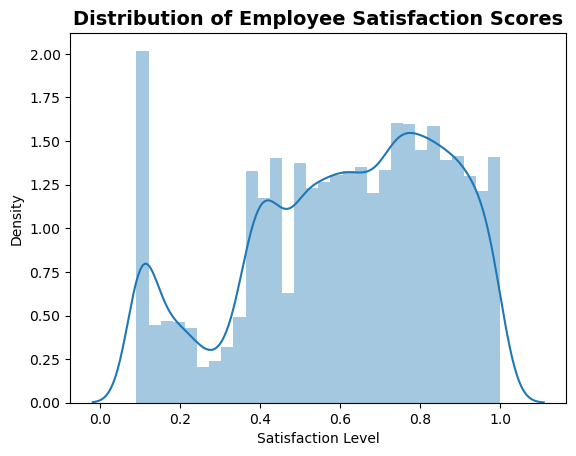

In [68]:
# univariate distribution 
sns.distplot(df['satisfaction_level'], kde=True, bins=30)
plt.title('Distribution of Employee Satisfaction Scores', fontsize=14, fontweight='bold')
plt.xlabel('Satisfaction Level')
plt.ylabel('Density')
plt.show()

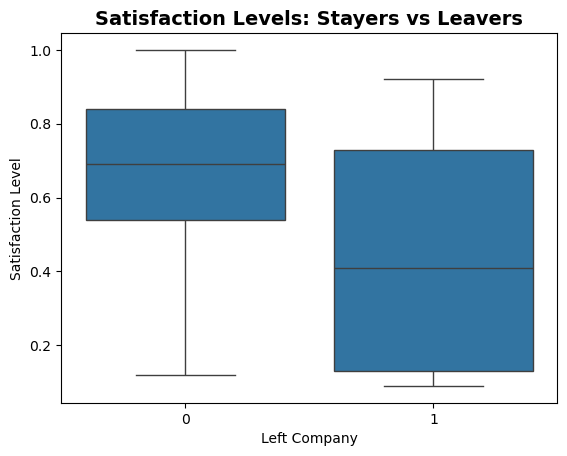

In [69]:
sns.boxplot(x='left', y='satisfaction_level', data=df)
plt.title('Satisfaction Levels: Stayers vs Leavers', fontsize=14, fontweight='bold')
plt.xlabel('Left Company')
plt.ylabel('Satisfaction Level')
plt.show()

The turnover of the employees who were left was not that much satisfied. This is a well, duh, situation in the sphere of data analysis - miserable people do go. But that is well to have the statistics corroborate our sense!

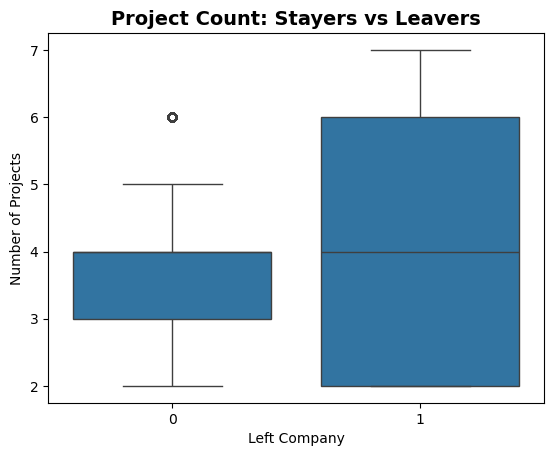

In [70]:
sns.boxplot(x='left', y='number_project', data=df)
plt.title('Project Count: Stayers vs Leavers', fontsize=14, fontweight='bold')
plt.xlabel('Left Company')
plt.ylabel('Number of Projects')
plt.show()

50% of Employees left when number_projects is between 3-4.
The dot outside the wishker at number_project = 6 is an outlier.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_23500\929469389.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['last_evaluation'], kde=True, bins=30)


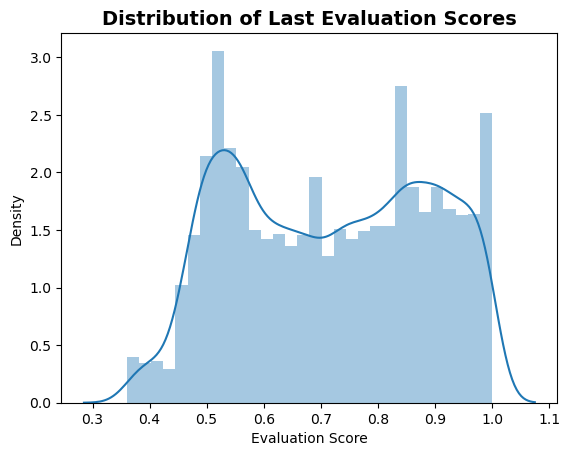

In [71]:
sns.distplot(df['last_evaluation'], kde=True, bins=30)
plt.title('Distribution of Last Evaluation Scores', fontsize=14, fontweight='bold')
plt.xlabel('Evaluation Score')
plt.ylabel('Density')
plt.show()

Evaluation score alone does not strongly separate leavers vs stayers.

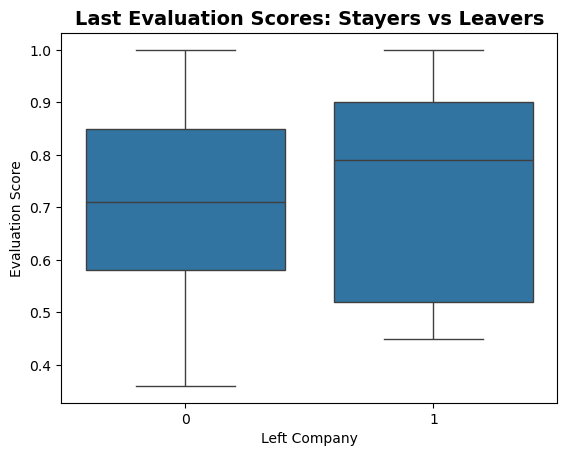

In [72]:
sns.boxplot(x='left', y='last_evaluation', data=df)
plt.title('Last Evaluation Scores: Stayers vs Leavers', fontsize=14, fontweight='bold')
plt.xlabel('Left Company')
plt.ylabel('Evaluation Score')
plt.show()

The score of evaluation does not have a strong difference between leavers and stayers. The ranges in the two groups are similar. Performance reviews may not be the most effective predictor of the one who will leave.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_23500\2856627192.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['average_monthly_hours'], kde=True, bins=30)


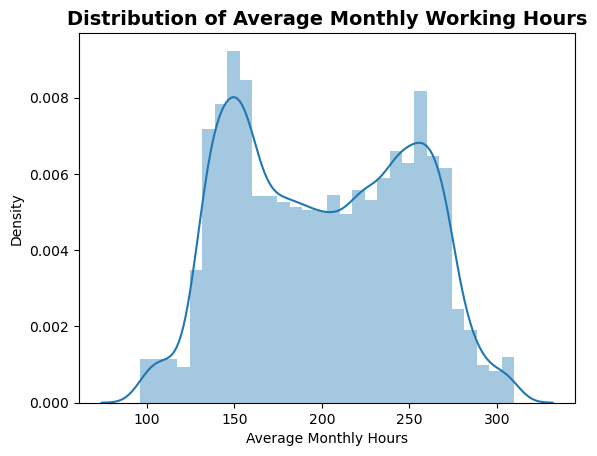

In [73]:
sns.distplot(df['average_monthly_hours'], kde=True, bins=30)
plt.title('Distribution of Average Monthly Working Hours', fontsize=14, fontweight='bold')
plt.xlabel('Average Monthly Hours')
plt.ylabel('Density')
plt.show()

Employees working very high hours are more likely to leave.

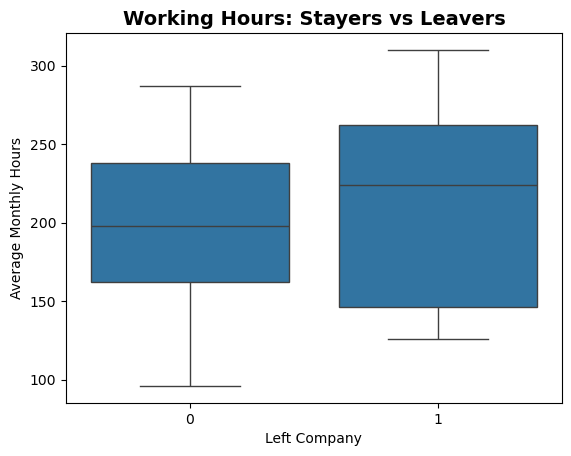

In [74]:
sns.boxplot(x="left", y="average_monthly_hours", data=df)
plt.title('Working Hours: Stayers vs Leavers', fontsize=14, fontweight='bold')
plt.xlabel('Left Company')
plt.ylabel('Average Monthly Hours')
plt.show()

This last one is self-evident - The longer the hours worked by an employee the greater the chances of leaving. Burnout comes to mind when I look at this. An individual can manage only to a threshold after which he or she requires a change. Definitely, overworking is a causative agent of attrition.

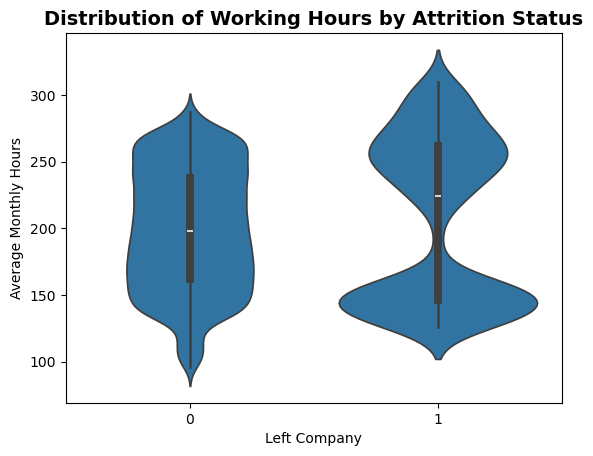

In [75]:
# A more visually rich plot that combines the density distribution with box plot
sns.violinplot(x="left", y="average_monthly_hours", data=df)
plt.title('Distribution of Working Hours by Attrition Status', fontsize=14, fontweight='bold')
plt.xlabel('Left Company')
plt.ylabel('Average Monthly Hours')
plt.show()

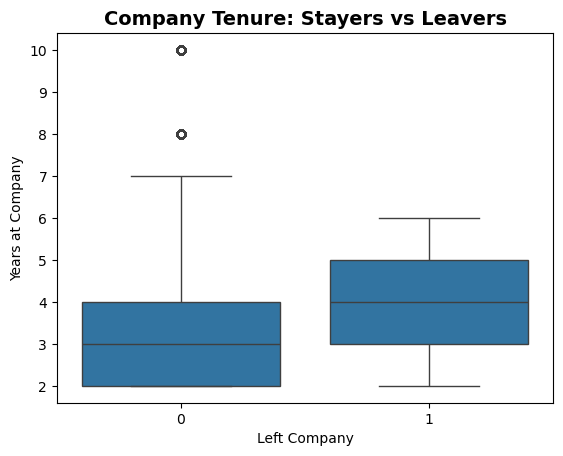

In [76]:
sns.boxplot(x="left", y="time_spend_company", data=df)
plt.title('Company Tenure: Stayers vs Leavers', fontsize=14, fontweight='bold')
plt.xlabel('Left Company')
plt.ylabel('Years at Company')
plt.show()

Also the employees that had been in the organization longer have higher probabilities of leaving. This sounds paradoxical, but as I consider it, what might happen is that people might leave at some point in their tenure because it is no longer stimulating and they might have an opportunity elsewhere. This period of 3-5 years appears to be very risky.

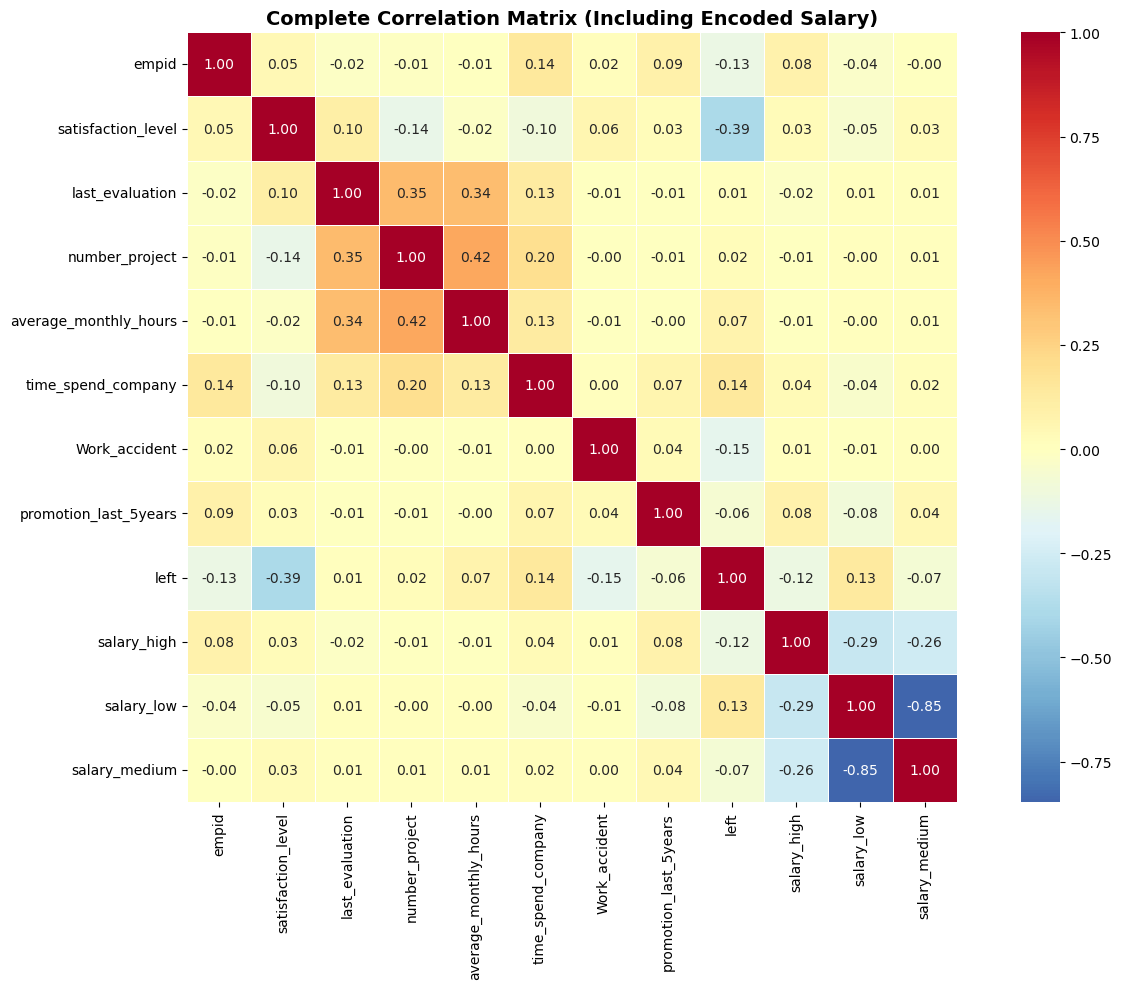

In [77]:
# Alternative: Create a copy with all categorical variables encoded
df_encoded = df.copy()

# One-hot encode the salary column (creates separate columns for each category)
salary_dummies = pd.get_dummies(df['salary'], prefix='salary')
df_encoded = pd.concat([df_encoded, salary_dummies], axis=1)

# Drop the original string column
df_encoded = df_encoded.drop('salary', axis=1)

# Now calculate correlation on all numeric columns
plt.figure(figsize=(14, 10))
cor_mat = df_encoded.corr()
sns.heatmap(cor_mat, annot=True, cmap='RdYlBu_r', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Complete Correlation Matrix (Including Encoded Salary)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

It is a heatmap that provides me with the bird eye view of relationships. Colors of red and blue indicate positive or negative correlation respectively. The relationship is the stronger it is dark in color.

A few things jump out:

The level of satisfaction is negatively correlated with leaving (that is, it makes sense)

There is a positive correlation between the number of projects and hours per month (the more the projects, the more the hours).

The league of salary has a few interesting trends.

In [ ]:
# Let's look at relationships between multiple variables at once
# I'm using a sample of 1000 rows to keep things manageable
sample_df = df_encoded.sample(n=1000, random_state=42)
sns.pairplot(sample_df, hue='left', 
             vars=['satisfaction_level', 'last_evaluation', 
                   'number_project', 'average_monthly_hours', 
                   'time_spend_company'])
plt.suptitle('Pairwise Relationships in Employee Data', y=1.02, fontsize=14, fontweight='bold')
plt.show()

Having interacted with this data, the following is what I find interesting:

Satisfaction is king - It is the best distinguishing factor of stayers versus leavers.

Money talks - Stiff pay is associated with increased attrition.

Career advancement is important - Promotion lacks and people are driven out.

Work life balance is a fact - too many hours result in burnout and resignation.

The 3-5 year risky - Around this time period, the higher the tenure, the higher the attrition.

These insights do not just consist of numbers but a story of what makes people stay or to leave. As our second step, I will use these findings to inform feature selection and model building. Other variables (such as work accidents) may not contribute to many predictive variables but satisfaction and working hours will be important.